<a href="https://colab.research.google.com/github/rohit-jain8/econ3916-lab03-visualization/blob/main/econ3916_lab03_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Good, Bad, and Ugly — Honest vs. Misleading Visualizations
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 6 min Part 0 + 50 minutes

---

**Learning Objectives:**
- Recreate Anscombe's Quartet and compute summary statistics that hide the visual differences
- Calculate the Lie Factor for a truncated-axis chart and redesign it honestly
- Build four visualizations of the same FRED wage data that tell four different stories
- Run a systematic EDA workflow on World Bank WDI data: structure, distributions, relationships, anomalies

**Dataset:** Anscombe's Quartet (seaborn), FRED wages, World Bank WDI

**Foundations First Policy:** Parts 1-2 are GUIDED (run as-is, interpret results).
Parts 3-4 have YOUR TURN sections. Part 5 is your submission.

**Prerequisites:** Part 0 of this lab (below), plus matplotlib basics from Labs 1-2,
Chapter 3 reading (Anscombe, Lie Factor, Data-Ink Ratio)

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

---

## Setup

<!-- idiom-note -->
> ### New idiom — three loop helpers, and `try` / `except`
>
> This lab's plotting code uses four shapes you have not written yet. You will
> **read** them here and rarely write them; recognising them is enough.
>
> | Shape | Read it as |
> |---|---|
> | `for i, ax in enumerate(axes):` | walk a list *while counting positions* — `i` is 0, 1, 2 … |
> | `for name, value in zip(a, b):` | walk two lists side by side, one pair per step |
> | `for _ in range(4):` | do this four times; `_` means "I do not need the value" |
> | `try: ... except ValueError: ...` | attempt something, and handle **one specific** failure rather than stopping |
>
> On the last one: always catch the narrow exception you expect
> (`KeyError`, `ValueError`). A bare `except:` swallows real bugs and leaves
> you debugging blind.


In [3]:
# -----------------------------------------------------------
# Install packages + imports (Google Colab)
# -----------------------------------------------------------
!pip install seaborn matplotlib numpy pandas -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Clean, publication-ready style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete!")

Setup complete!


### A word on seaborn, since this is the first time you have seen it

`seaborn` (imported as `sns`) is a thin layer on top of matplotlib. It does not
replace matplotlib — it calls it. You use it for two things in this lab:

- **`sns.load_dataset("anscombe")`** downloads one of about twenty small classic
  teaching datasets that seaborn hosts on GitHub, and hands it back as a DataFrame.
  It is a fixture, not your data: the name is fixed, the contents never change, and
  every textbook that uses Anscombe's Quartet is using these same 44 rows. It needs
  an internet connection, nothing else.
- **Statistical chart types** that would take a dozen matplotlib lines to build by
  hand — `sns.regplot`, `sns.boxplot`, `sns.heatmap`. Each one returns a matplotlib
  axes, so everything you learned about `ax.set_xlabel(...)` still applies.

One thing that is *not* seaborn: `plt.style.use("seaborn-v0_8-whitegrid")` in the
cell above. That is matplotlib wearing seaborn's colour scheme, and it works whether
or not seaborn is installed. The `v0_8` in the name is matplotlib recording which
version of seaborn's look it copied.

Everything in this lab is a DataFrame going into a matplotlib axes, exactly as in
Labs 0-2.

<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 6 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** how a matplotlib figure is actually built — `fig`, `ax`, and `savefig`.

This lab is about whether a chart tells the truth. Before judging one, you need
to know which line of code made which part of it.


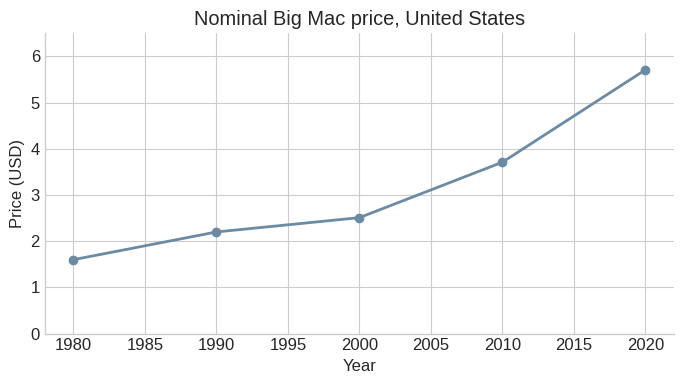

Saved to figures/ch03_step0.png
fig is a Figure; ax is an Axes


In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: how a matplotlib figure is actually built
# -----------------------------------------------------------
from pathlib import Path

# A fresh Colab session has no figures/ directory, and savefig will NOT create
# one. Every lab in this course makes it first, exactly like this.
Path("figures").mkdir(exist_ok=True)

# plt.subplots() hands back TWO things: the FIGURE (the sheet of paper) and the
# AXES (the plot drawn on it). You draw on `ax`, and you save `fig`. Almost
# every chart you meet in this course starts with this line.
fig, ax = plt.subplots(figsize=(7, 4))

years  = [1980, 1990, 2000, 2010, 2020]
prices = [1.60, 2.20, 2.51, 3.71, 5.71]

ax.plot(years, prices, marker="o", color="#6B8BA4", linewidth=2)

# The three labels are not decoration. An unlabelled axis is the most common
# way an honest chart still misleads, which is what this whole lab is about.
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD)")
ax.set_title("Nominal Big Mac price, United States")

# The y-axis starting at zero is a CHOICE. Part 2 is about what that choice
# does to a reader. Setting it explicitly is how you take responsibility for it.
ax.set_ylim(0, 6.5)

plt.tight_layout()
plt.savefig("figures/ch03_step0.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to figures/ch03_step0.png")
print(f"fig is a {type(fig).__name__}; ax is an {type(ax).__name__}")

## Part 1: Anscombe's Quartet — When Statistics Lie (GUIDED — 10 min)

In 1973, statistician Francis Anscombe constructed four datasets that share **identical** summary statistics but look completely different when plotted. This is the single most important lesson in data visualization: *never trust summary statistics without plotting the data.*

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Load Anscombe's Quartet and compute summary stats
# -----------------------------------------------------------
anscombe = sns.load_dataset("anscombe")
print(f"Shape: {anscombe.shape}")
print(f"Datasets: {anscombe['dataset'].unique()}\n")

# Compute summary statistics for all four datasets
correlations = anscombe.groupby("dataset").apply(
    lambda d: d["x"].corr(d["y"])
).round(3)

summary = anscombe.groupby("dataset").agg(
    x_mean=("x", "mean"),
    y_mean=("y", lambda y: round(y.mean(), 2)),
    x_var=("x", "var"),
    y_var=("y", lambda y: round(y.var(), 2)),
)
summary["correlation"] = correlations

print("Summary statistics for all four datasets:")
print("=" * 60)
print(summary.to_string())
print("\nRegression line for all four: y = 3.0 + 0.5x")
print("\nThe statistics are virtually identical!")
print("An analyst looking only at these numbers would conclude")
print("the four datasets are interchangeable. They are NOT.")

Shape: (44, 3)
Datasets: ['I' 'II' 'III' 'IV']

Summary statistics for all four datasets:
         x_mean  y_mean  x_var  y_var  correlation
dataset                                           
I           9.0     7.5   11.0   4.13        0.816
II          9.0     7.5   11.0   4.13        0.816
III         9.0     7.5   11.0   4.12        0.816
IV          9.0     7.5   11.0   4.12        0.817

Regression line for all four: y = 3.0 + 0.5x

The statistics are virtually identical!
An analyst looking only at these numbers would conclude
the four datasets are interchangeable. They are NOT.


/tmp/ipykernel_2940/1876492906.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = anscombe.groupby("dataset").apply(


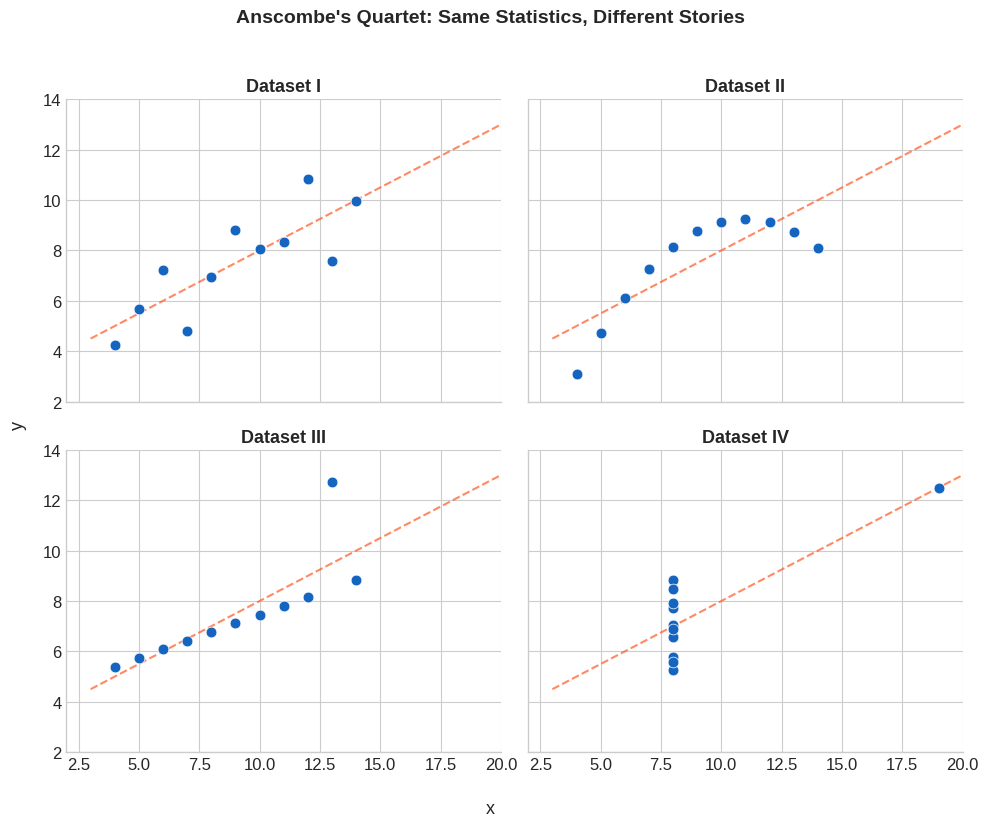

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Plot all four datasets as a 2x2 grid
# with the shared regression line y = 3 + 0.5x overlaid
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

datasets = ["I", "II", "III", "IV"]
x_line = np.linspace(3, 20, 100)
y_line = 3.0 + 0.5 * x_line  # The shared regression line

for ax, ds in zip(axes.flatten(), datasets):
    subset = anscombe[anscombe["dataset"] == ds]
    ax.scatter(subset["x"], subset["y"], s=60, color="#1565C0",
              edgecolors="white", linewidth=0.5, zorder=3)
    ax.plot(x_line, y_line, color="#FF5722", linewidth=1.5,
            linestyle="--", alpha=0.7, label="y = 3 + 0.5x")
    ax.set_title(f"Dataset {ds}", fontsize=13, fontweight="bold")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

fig.supxlabel("x", fontsize=13)
fig.supylabel("y", fontsize=13)
fig.suptitle("Anscombe's Quartet: Same Statistics, Different Stories",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation Questions

**Q1:** Which dataset would make OLS regression most misleading? Why?

**Q2:** Dataset III has one outlier that pulls the regression line away from the otherwise perfect linear pattern. How would removing that single point change the correlation?

**Q3:** What is the lesson for your own data analysis workflow? When in the analysis pipeline should visualization happen?

*Your answers here:*

1. Dataset IV would make OLS regression most misleading because almost all of the x-values are the same, and one extreme point is driving the positive regression line. Without that one point, there would be basically no relationship between x and y, so the regression line gives a misleading picture of the data.
2. Removing the outlier would make the correlation much stronger and bring it very close to 1 because the remaining points follow an almost perfect positive linear relationship.
3. The main lesson is that summary statistics and regression results alone can hide important patterns in the data. Visualization should happen early in the analysis process, before relying on statistical models, so that I can identify outliers, nonlinear relationships, and other patterns that the summary statistics might miss.

## Part 2: Lie Factor and Honest Redesign (GUIDED — 10 min)

Edward Tufte's **Lie Factor** quantifies how much a chart exaggerates or understates the data:

$$\text{Lie Factor} = \frac{\text{Size of effect shown in the graphic}}{\text{Size of effect in the data}}$$

A Lie Factor of 1.0 means the chart is perfectly honest. Values far from 1.0 indicate distortion.

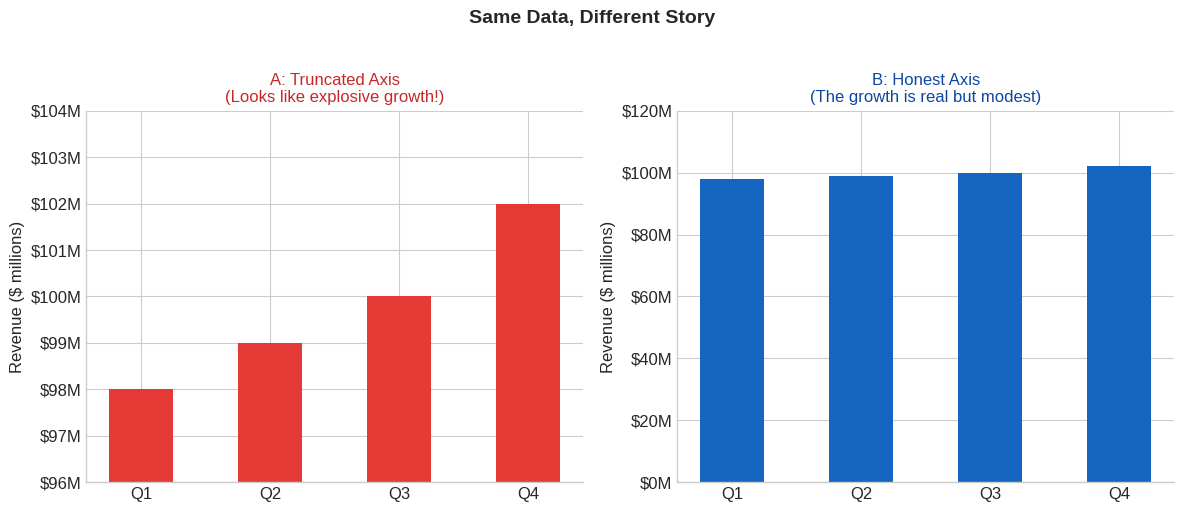

In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Truncated vs. honest bar chart (side by side)
# A company wants to impress investors with a "growth" chart
# -----------------------------------------------------------
quarters = ["Q1", "Q2", "Q3", "Q4"]
revenue = [98, 99, 100, 102]  # Millions of dollars

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: TRUNCATED y-axis (starts at 96M) — dishonest
axes[0].bar(quarters, revenue, color="#E53935", width=0.5)
axes[0].set_ylim(96, 104)
axes[0].set_ylabel("Revenue ($ millions)")
axes[0].set_title("A: Truncated Axis\n(Looks like explosive growth!)",
                   fontsize=12, color="#C62828")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}M"))

# Panel B: HONEST y-axis (starts at 0) — truthful
axes[1].bar(quarters, revenue, color="#1565C0", width=0.5)
axes[1].set_ylim(0, 120)
axes[1].set_ylabel("Revenue ($ millions)")
axes[1].set_title("B: Honest Axis\n(The growth is real but modest)",
                   fontsize=12, color="#0D47A1")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}M"))

fig.suptitle("Same Data, Different Story", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Calculate the Lie Factor step by step
# -----------------------------------------------------------

# The DATA effect: actual percentage change from Q1 to Q4
data_effect = (102 - 98) / 98
print(f"Data effect (actual change): (102 - 98) / 98 = {data_effect:.4f} = {data_effect*100:.1f}%")

# The VISUAL effect in the truncated chart:
# Q1 bar height on screen: 98 - 96 = 2 units
# Q4 bar height on screen: 102 - 96 = 6 units
visual_effect = (6 - 2) / 2
print(f"Visual effect (perceived change): (6 - 2) / 2 = {visual_effect:.4f} = {visual_effect*100:.0f}%")

# Lie Factor = visual / data
lie_factor = visual_effect / data_effect
print(f"\nLie Factor = {visual_effect:.2f} / {data_effect:.4f} = {lie_factor:.1f}")
print(f"\nThe truncated chart makes the change look {lie_factor:.0f}x larger than it really is.")
print(f"A 4% real increase LOOKS like a 200% increase on screen.")

Data effect (actual change): (102 - 98) / 98 = 0.0408 = 4.1%
Visual effect (perceived change): (6 - 2) / 2 = 2.0000 = 200%

Lie Factor = 2.00 / 0.0408 = 49.0

The truncated chart makes the change look 49x larger than it really is.
A 4% real increase LOOKS like a 200% increase on screen.


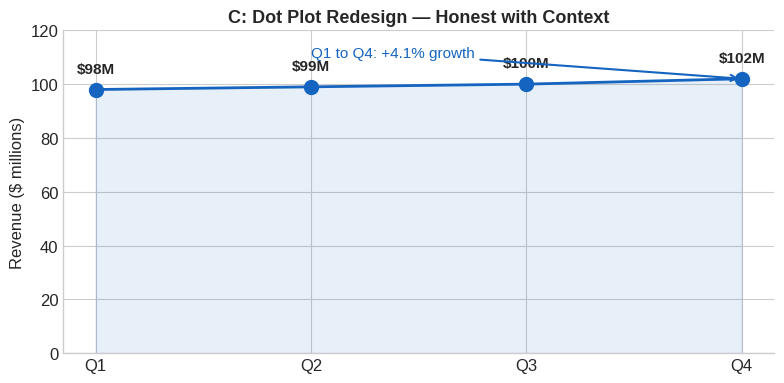

The dot plot shows the honest scale AND labels the actual change.
No need to truncate the axis to make the story visible.


In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 5: Redesign as a dot plot — honest AND informative
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(quarters, revenue, marker="o", markersize=10, color="#1565C0",
        linewidth=2, zorder=3)
ax.fill_between(quarters, revenue, alpha=0.1, color="#1565C0")

for q, r in zip(quarters, revenue):
    ax.annotate(f"${r}M", (q, r), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 120)
ax.set_ylabel("Revenue ($ millions)")
ax.set_title("C: Dot Plot Redesign — Honest with Context", fontsize=13, fontweight="bold")
ax.annotate("Q1 to Q4: +4.1% growth",
            xy=("Q4", 102), xytext=("Q2", 110), fontsize=11, color="#1565C0",
            arrowprops=dict(arrowstyle="->", color="#1565C0", lw=1.5))

plt.tight_layout()
plt.show()

print("The dot plot shows the honest scale AND labels the actual change.")
print("No need to truncate the axis to make the story visible.")

### Interpretation Questions

**Q1:** A colleague shows you a chart with Lie Factor = 12. What does that mean in plain English?

**Q2:** When is starting the y-axis at a non-zero value acceptable? Give a specific example from economics.

*Your answers here:*

1. A Lie Factor of 12 means the chart makes the change look 12 times bigger than it actually is. Basically, the visual is exaggerating how large the real change in the data is.
2. Starting the y-axis at a non-zero value can be acceptable when you are trying to make smaller changes in the data easier to see, as long as the scale is clearly shown and not misleading. For example, if the unemployment rate increased from 4.0% to 4.5%, starting the y-axis around 3.5% could make that change easier to see.

## Part 3: Four Versions of One Dataset (YOUR TURN — 15 min)

Now we load real (deflated) wage data and build four panels that each tell a different story from the **same underlying numbers.** This is the core ethics lesson: visualization is a rhetorical choice.


In [10]:
# -----------------------------------------------------------
# Step 6: Load FRED earnings data and deflate it
#
# Two series, no API key needed: nominal average hourly earnings
# (AHETPI, production workers, monthly since 1964) and the CPI
# (CPIAUCSL). Chapter 2's rule applies -- a wage in 1964 dollars and a
# wage in 2025 dollars are not the same unit, so we convert both to
# 2020 dollars before plotting anything.
#
# FRED's CSV header is the series ID, and the date column has been
# renamed before now. We read the columns positionally so a header
# change cannot silently reshape the data.
# -----------------------------------------------------------
def load_fred(series_id, start="1964-01-01", end=None):
    """Return a one-column DataFrame indexed by date. Raises if FRED is down.

    With no `end`, you get everything FRED has published so far.
    """
    url = (f"https://fred.stlouisfed.org/graph/fredgraph.csv?"
           f"id={series_id}&cosd={start}")
    if end is not None:
        url += f"&coed={end}"
    df = pd.read_csv(url)
    df.columns = ["date", series_id]          # positional, not by name
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date").dropna()

nominal = load_fred("AHETPI")      # avg hourly earnings, production workers
cpi = load_fred("CPIAUCSL")        # consumer price index

wages = nominal.join(cpi, how="inner").dropna()
base = wages.loc["2020", "CPIAUCSL"].mean()   # 2020 = base year
wages["wage"] = wages["AHETPI"] * base / wages["CPIAUCSL"]

print(f"Loaded FRED data: {len(wages)} observations")
print(f"Date range: {wages.index.min().date()} to {wages.index.max().date()}")
print(f"Nominal:      ${wages['AHETPI'].iloc[0]:.2f}  ->  ${wages['AHETPI'].iloc[-1]:.2f}")
print(f"Real (2020$): ${wages['wage'].iloc[0]:.2f}  ->  ${wages['wage'].iloc[-1]:.2f}")
print()
print("Nominal earnings rose more than twelvefold. Real earnings rose about")
print("twenty percent in sixty years, and fell for most of the middle forty.")
print("Every panel below plots the REAL series -- the deflated one.")


Loaded FRED data: 751 observations
Date range: 1964-01-01 to 2026-08-01
Nominal:      $2.50  ->  $32.53
Real (2020$): $20.92  ->  $25.20

Nominal earnings rose more than twelvefold. Real earnings rose about
twenty percent in sixty years, and fell for most of the middle forty.
Every panel below plots the REAL series -- the deflated one.


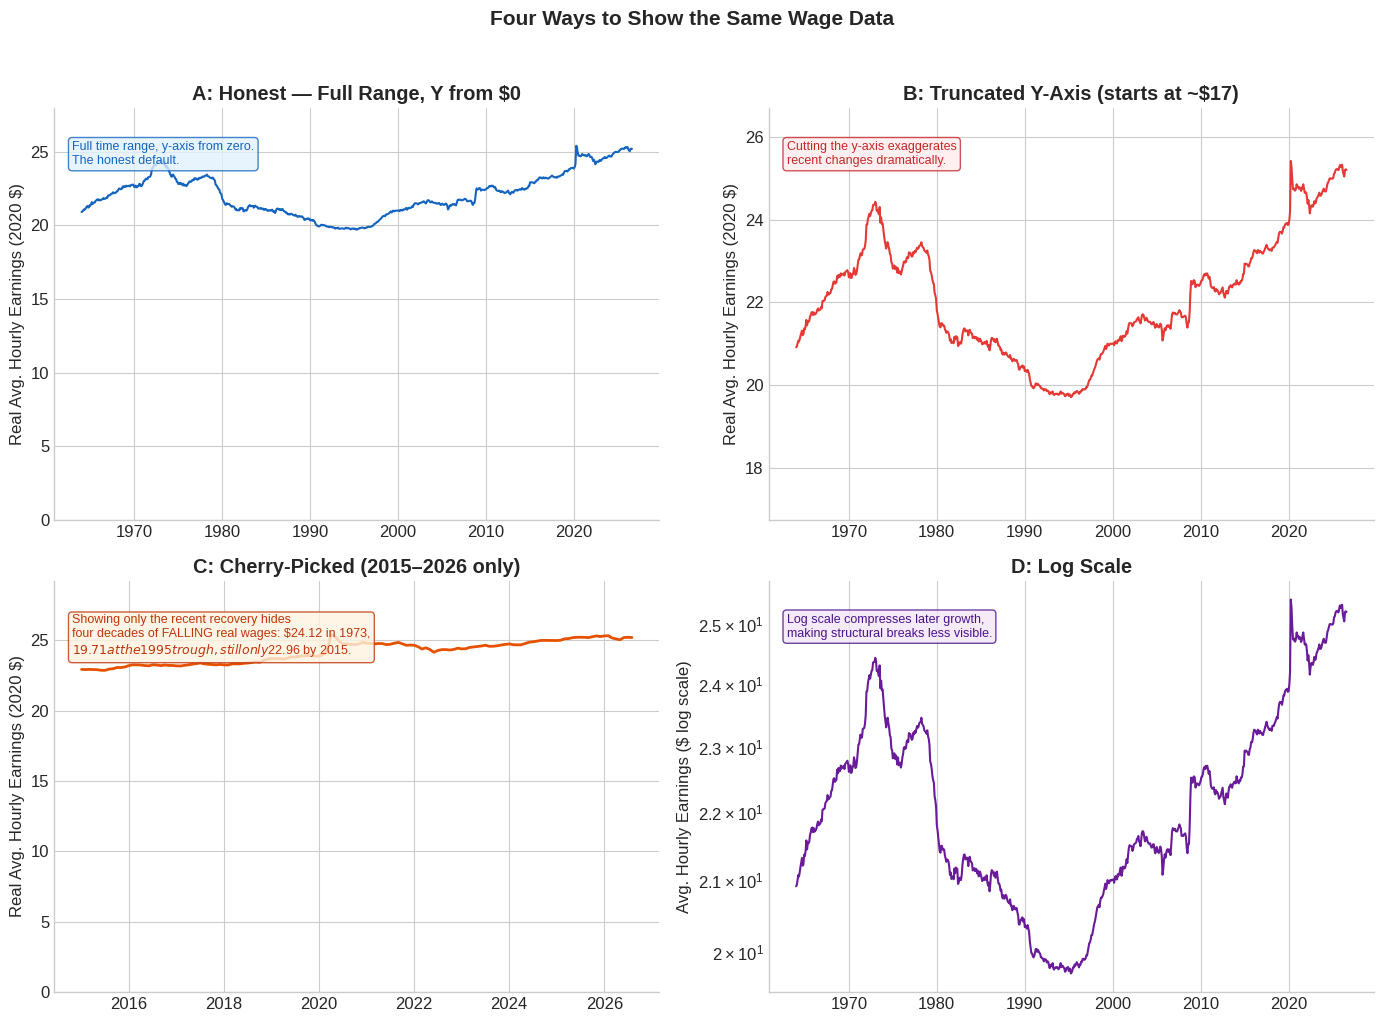

In [11]:
# -----------------------------------------------------------
# Step 7: Four panels, four stories, one dataset
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel A: HONEST (full range, y from 0) ---
ax = axes[0, 0]
ax.plot(wages.index, wages["wage"], color="#1565C0", linewidth=1.5)
ax.set_ylim(0, wages["wage"].max() * 1.1)
ax.set_title("A: Honest — Full Range, Y from $0", fontweight="bold")
ax.set_ylabel("Real Avg. Hourly Earnings (2020 $)")
ax.annotate("Full time range, y-axis from zero.\nThe honest default.",
            xy=(0.03, 0.92), xycoords="axes fraction", fontsize=9, va="top",
            color="#1565C0",
            bbox=dict(boxstyle="round,pad=0.3", fc="#E3F2FD", ec="#1565C0", alpha=0.8))

# --- Panel B: TRUNCATED y-axis ---
ax = axes[0, 1]
ax.plot(wages.index, wages["wage"], color="#E53935", linewidth=1.5)
ax.set_ylim(wages["wage"].min() * 0.85, wages["wage"].max() * 1.05)
ax.set_title(f"B: Truncated Y-Axis (starts at ~${wages['wage'].min() * 0.85:.0f})",
             fontweight="bold")
ax.set_ylabel("Real Avg. Hourly Earnings (2020 $)")
ax.annotate("Cutting the y-axis exaggerates\nrecent changes dramatically.",
            xy=(0.03, 0.92), xycoords="axes fraction", fontsize=9, va="top",
            color="#C62828",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFEBEE", ec="#C62828", alpha=0.8))

# --- Panel C: CHERRY-PICKED time window ---
ax = axes[1, 0]
recent = wages.loc["2015":]
ax.plot(recent.index, recent["wage"], color="#E65100", linewidth=2)
ax.set_ylim(0, recent["wage"].max() * 1.15)
ax.set_title(f"C: Cherry-Picked ({recent.index[0].year}–{recent.index[-1].year} only)", fontweight="bold")
ax.set_ylabel("Real Avg. Hourly Earnings (2020 $)")
ax.annotate("Showing only the recent recovery hides\nfour decades of FALLING real wages: $24.12 in 1973,\n$19.71 at the 1995 trough, still only $22.96 by 2015.",
            xy=(0.03, 0.92), xycoords="axes fraction", fontsize=9, va="top",
            color="#BF360C",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFF3E0", ec="#BF360C", alpha=0.8))

# --- Panel D: LOG SCALE ---
ax = axes[1, 1]
ax.plot(wages.index, wages["wage"], color="#6A1B9A", linewidth=1.5)
ax.set_yscale("log")
ax.set_title("D: Log Scale", fontweight="bold")
ax.set_ylabel("Avg. Hourly Earnings ($ log scale)")
ax.annotate("Log scale compresses later growth,\nmaking structural breaks less visible.",
            xy=(0.03, 0.92), xycoords="axes fraction", fontsize=9, va="top",
            color="#4A148C",
            bbox=dict(boxstyle="round,pad=0.3", fc="#F3E5F5", ec="#4A148C", alpha=0.8))

fig.suptitle("Four Ways to Show the Same Wage Data",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Interpretation Questions

**Q1:** If you were a union negotiator trying to argue that workers deserve higher wages, which panel would you show management? Why?

**Q2:** If you were a Fed economist writing a policy report, which panel is the most appropriate? Why?

**Q3:** Panel D uses a log scale. For what types of economic data IS a log scale the honest choice? Give two examples.

*Your answers here:*

1. I would show Panel C because it focuses only on the more recent years, where real wages have stayed pretty flat. This would help support the argument that workers deserve higher wages because there has not been much real wage growth recently.
2. I would use Panel A because it shows the full time period and starts the y-axis at zero, giving the most complete and honest picture of how real wages have changed over time. It avoids exaggerating certain changes or leaving out important parts of the data.
3. A log scale is useful for economic data that grows a lot over time or covers a very large range of values because it makes percentage changes easier to compare. Two examples would be GDP over a long period of time and stock market prices over several decades.

## Part 4: Systematic EDA on World Bank Data (YOUR TURN — 15 min)

A complete EDA follows a checklist: **Structure → Distributions → Relationships → Anomalies.** We walk through each step using World Bank GDP data.

In [12]:
# -----------------------------------------------------------
# Step 8: Load World Bank GDP data + Structure check
# -----------------------------------------------------------
try:
    url_wb = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"
    gdp = pd.read_csv(url_wb)
    print(f"Loaded World Bank GDP data: {gdp.shape}")
except Exception as e:
    # Do NOT fabricate data here. An earlier version of this lab generated a
    # synthetic panel on failure and printed one line about it, which is easy
    # to scroll past -- and every number you then computed was invented.
    raise RuntimeError(
        "Could not load the World Bank GDP file. Check your connection and "
        "re-run; do not continue with substitute data.\n"
        f"  source: {url_wb}\n  cause : {e!r}") from e

if False:  # retained only to show what the old fallback did; never runs
    np.random.seed(42)
    countries = ["USA", "CHN", "JPN", "DEU", "GBR", "IND", "FRA", "BRA",
                 "CAN", "KOR", "AUS", "MEX", "IDN", "NLD", "SAU", "TUR",
                 "CHE", "NGA", "ARG", "ZAF"]
    years = list(range(1960, 2024))
    rows = []
    base_gdps = np.exp(np.random.uniform(22, 30, len(countries)))
    for i, c in enumerate(countries):
        for y in years:
            growth = np.exp(0.04 * (y - 1960) + np.random.normal(0, 0.05))
            val = base_gdps[i] * growth
            if np.random.random() < 0.03:
                val = np.nan
            rows.append({"Country Name": c, "Country Code": c,
                        "Year": y, "Value": val})
    gdp = pd.DataFrame(rows)

# --- EDA STEP 1: Structure ---
print(f"\n{'='*50}")
print("EDA STEP 1: STRUCTURE")
print(f"{'='*50}")
print(f"Shape: {gdp.shape[0]} rows x {gdp.shape[1]} columns")
print(f"\nData types:\n{gdp.dtypes}")
print(f"\nUnique values per column:\n{gdp.nunique()}")

# Identify columns
value_col = [c for c in gdp.columns if c in ["Value", "value", "GDP", "gdp"]][0]
year_col = [c for c in gdp.columns if c.lower() == "year"][0]
country_col = [c for c in gdp.columns if "country" in c.lower() and "code" in c.lower()][0]

print(f"\nYear range: {gdp[year_col].min()} to {gdp[year_col].max()}")
print(f"Economies: {gdp[country_col].nunique()}")
print("  (not all are countries — World, Euro area, High income and other")
print("   aggregates are rows here too. Average across all of them and you")
print("   have counted much of the planet twice.)")
print(f"Missing GDP values: {gdp[value_col].isna().sum()} ({gdp[value_col].isna().mean()*100:.1f}%)")

Loaded World Bank GDP data: (13979, 4)

EDA STEP 1: STRUCTURE
Shape: 13979 rows x 4 columns

Data types:
Country Name     object
Country Code     object
Year              int64
Value           float64
dtype: object

Unique values per column:
Country Name      262
Country Code      262
Year               64
Value           13900
dtype: int64

Year range: 1960 to 2023
Economies: 262
  (not all are countries — World, Euro area, High income and other
   aggregates are rows here too. Average across all of them and you
   have counted much of the planet twice.)
Missing GDP values: 0 (0.0%)


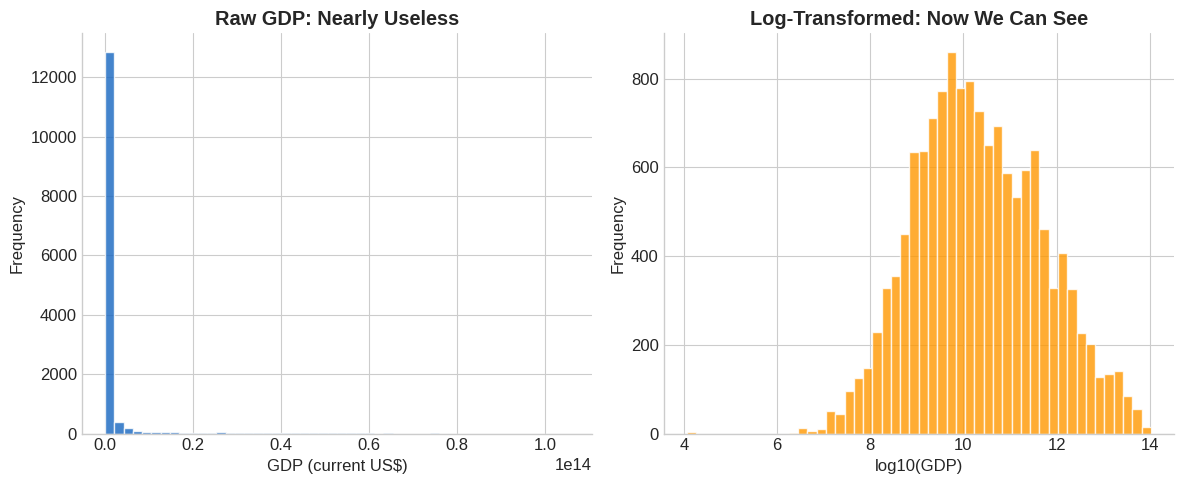

Skewness of raw GDP: 8.4
Skewness of log GDP: 0.2


In [13]:
# -----------------------------------------------------------
# Step 9: EDA STEP 2 — Distribution check
# Raw GDP histogram vs. log-transformed
# -----------------------------------------------------------
gdp_values = gdp[value_col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(gdp_values, bins=50, color="#1565C0", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("GDP (current US$)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw GDP: Nearly Useless", fontweight="bold")
axes[0].ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

log_gdp = np.log10(gdp_values[gdp_values > 0])
axes[1].hist(log_gdp, bins=50, color="#FF9800", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log10(GDP)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Transformed: Now We Can See", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Skewness of raw GDP: {gdp_values.skew():.1f}")
print(f"Skewness of log GDP: {log_gdp.skew():.1f}")

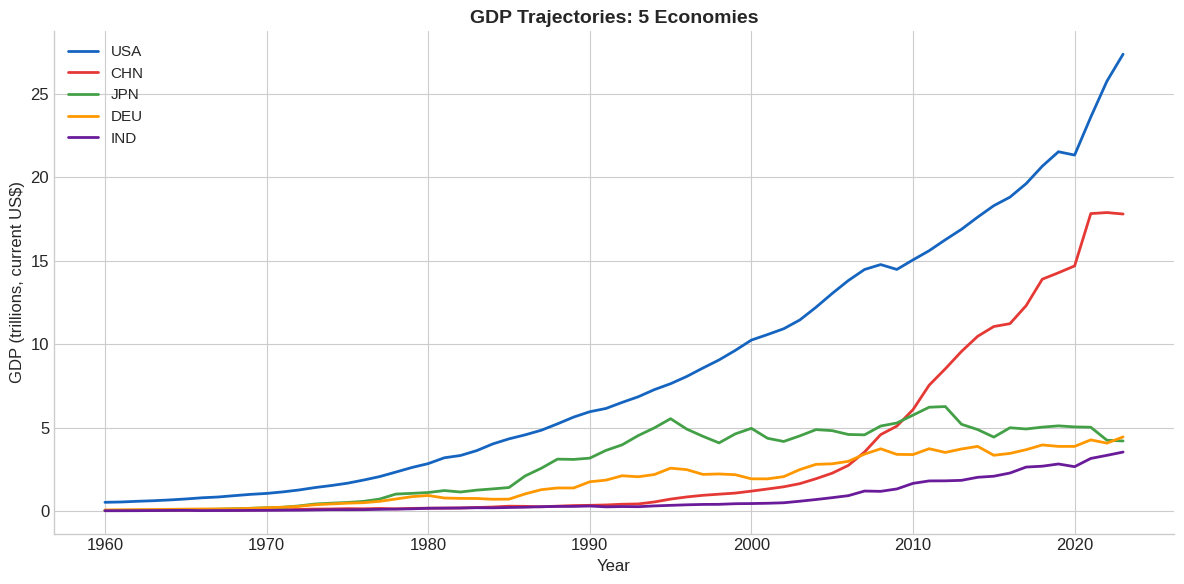

In [14]:
# -----------------------------------------------------------
# Step 10: EDA STEP 3 — Relationship check
# GDP trajectories for 5 countries
# -----------------------------------------------------------
focus_countries = ["USA", "CHN", "JPN", "DEU", "IND"]
colors_map = {"USA": "#1565C0", "CHN": "#E53935", "JPN": "#43A047",
              "DEU": "#FF9800", "IND": "#6A1B9A"}

fig, ax = plt.subplots(figsize=(12, 6))
for country in focus_countries:
    subset = gdp[gdp[country_col] == country].sort_values(year_col)
    ax.plot(subset[year_col], subset[value_col] / 1e12,
            label=country, linewidth=2, color=colors_map[country])

ax.set_xlabel("Year")
ax.set_ylabel("GDP (trillions, current US$)")
ax.set_title("GDP Trajectories: 5 Economies", fontsize=14, fontweight="bold")
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

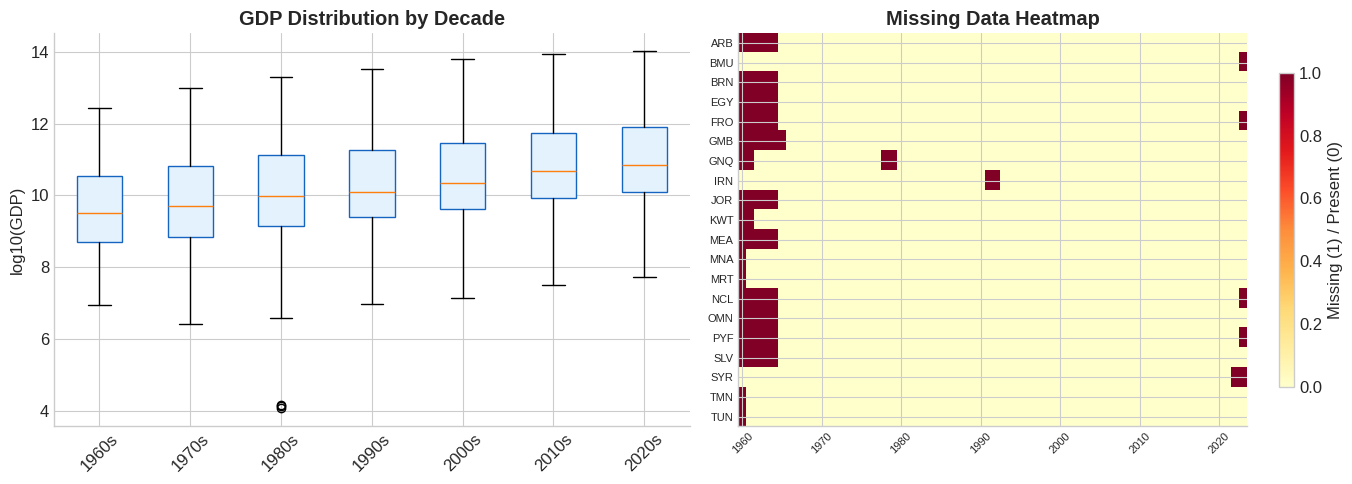

NaN cells in the long format:     0
Gaps visible in the pivoted panel: 74 of 1280 country-years
Negative GDP values (impossible): 0


In [15]:
# -----------------------------------------------------------
# Step 11: EDA STEP 4 — Anomaly check
# Box plot by decade + missing data heatmap
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Box plot of log GDP by decade
gdp_clean = gdp.dropna(subset=[value_col]).copy()
gdp_clean["decade"] = (gdp_clean[year_col] // 10) * 10
gdp_clean["log_gdp"] = np.log10(gdp_clean[value_col].clip(lower=1))

decades = sorted(gdp_clean["decade"].unique())
box_data = [gdp_clean.loc[gdp_clean["decade"] == d, "log_gdp"].values for d in decades]
bp = axes[0].boxplot(box_data, tick_labels=[str(int(d)) + "s" for d in decades],
                     patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#E3F2FD")
    patch.set_edgecolor("#1565C0")
axes[0].set_ylabel("log10(GDP)")
axes[0].set_title("GDP Distribution by Decade", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Panel B: Missing data heatmap
# Pick countries with PARTIAL coverage. Taking the twenty with the most
# observations selects twenty with complete records, so the heatmap comes
# out solid and Q2 below has nothing to read.
_counts = gdp[country_col].value_counts()
sample_countries = _counts[_counts < _counts.max()].head(20).index.tolist()
pivot = gdp[gdp[country_col].isin(sample_countries)].pivot_table(
    index=country_col, columns=year_col, values=value_col, aggfunc="first")
missing_matrix = pivot.isna().astype(int)

im = axes[1].imshow(missing_matrix.values, cmap="YlOrRd", aspect="auto",
                     interpolation="nearest")
axes[1].set_yticks(range(len(missing_matrix.index)))
axes[1].set_yticklabels(missing_matrix.index, fontsize=8)
year_labels = missing_matrix.columns.tolist()
tick_positions = list(range(0, len(year_labels), 10))
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels([str(int(year_labels[i])) for i in tick_positions],
                         rotation=45, fontsize=8)
axes[1].set_title("Missing Data Heatmap", fontweight="bold")
plt.colorbar(im, ax=axes[1], label="Missing (1) / Present (0)", shrink=0.8)

plt.tight_layout()
plt.show()

# Careful: gdp[value_col].isna() is 0 by construction -- the World Bank file
# stores a gap as an ABSENT ROW, not as a NaN. The missingness only becomes
# visible once you pivot to country x year, which is what the heatmap does.
print(f"NaN cells in the long format:     {gdp[value_col].isna().sum()}")
print(f"Gaps visible in the pivoted panel: {int(missing_matrix.values.sum())} "
      f"of {missing_matrix.size} country-years")
print(f"Negative GDP values (impossible): {(gdp[value_col] < 0).sum()}")

### EDA Checklist Summary

| Step | Question | Tool | What We Found |
|------|----------|------|---------------|
| **Structure** | What shape is the data? Panel/cross-section/time series? | `.shape`, `.dtypes`, `.nunique()` | Panel: many countries x many years |
| **Distributions** | Is the data skewed? Are there impossible values? | Histograms, `.describe()` | Extremely right-skewed; log transform needed |
| **Relationships** | What patterns exist between variables or over time? | Line plots, scatter plots | China's rapid rise; US still largest |
| **Anomalies** | Missing data? Outliers? Impossible values? | Box plots, missing heatmap | Coverage is thin early and thin again at the very end: ~85% of these countries are missing in 1960 and ~25% in 2023, against none in between |

### Interpretation Questions

**Q1:** Why is the raw GDP histogram nearly useless? What transformation fixes it, and why does it work?

**Q2:** Look at the missing data heatmap. The gaps sit at the two ends of the period, not scattered through it. Is that missingness MCAR (completely at random), MAR (at random conditional on observed data), or MNAR (not at random)? Explain your reasoning.

*Your answers here:*

1. The raw GDP histogram is nearly useless because GDP values vary so much across countries that the largest economies stretch out the scale and cause most of the data to bunch together. Taking the log of GDP fixes this by compressing the really large values, making the overall distribution much easier to see and compare.
2. I would consider this MAR because the missing values follow a clear pattern based on the year rather than being completely random. Most of the missing data is at the beginning and end of the time period, while there is basically none in between, so the chance of a value being missing seems related to an observed variable, which in this case is the year.

### Before the expansion: save the data

The toggler you are about to build runs on `wages`, and anything you open
outside this notebook — another Colab, a script, a chat assistant — cannot see
it. The cell below writes the three datasets to disk and zips them.

One more reason here: **FRED revises**. These files pin the exact series you
worked with today, so your chart and your README keep agreeing with each other
next week.


In [16]:
# -----------------------------------------------------------
# GIVEN — run as-is: save the data so your chart can run
#         outside this notebook
# -----------------------------------------------------------
import zipfile

frames = {
    "wages.csv":         wages,      # AHETPI nominal, CPIAUCSL, wage = real 2020 $
    "anscombe.csv":      anscombe,   # the quartet, fixed data
    "worldbank_gdp.csv": gdp,        # 13,979 country-years, 1960-2023
}
for name, frame in frames.items():
    # wages is indexed by date and needs to keep it; the other two carry a
    # plain RangeIndex, which would come back as a stray "Unnamed: 0" column.
    frame.to_csv(name, index=(name == "wages.csv"))
    print(f"  wrote {name:<20} {frame.shape}")

bundle = "lab3_chart_bundle.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as z:
    for name in frames:
        z.write(name)
print(f"\nZipped to {bundle}.")
print("Reload it anywhere with:")
print('    wages = pd.read_csv("wages.csv", index_col=0, parse_dates=True)')
print("\nThe toggler needs two columns of that frame:")
print('    wages["AHETPI"]  nominal        wages["wage"]  real, 2020 dollars')

# In Colab this pushes the zip straight to your browser. Outside Colab it is
# skipped and the file simply sits next to this notebook.
try:
    from google.colab import files as _colab_files
    _colab_files.download(bundle)
except Exception:
    pass

  wrote wages.csv            (751, 3)
  wrote anscombe.csv         (44, 3)
  wrote worldbank_gdp.csv    (13979, 4)

Zipped to lab3_chart_bundle.zip.
Reload it anywhere with:
    wages = pd.read_csv("wages.csv", index_col=0, parse_dates=True)

The toggler needs two columns of that frame:
    wages["AHETPI"]  nominal        wages["wage"]  real, 2020 dollars


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## AI-Assisted Expansion: Honest-Chart Toggler

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over Anscombe's Quartet, the Lie Factor, four framings of one wage series, and a systematic EDA workflow. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive chart (ipywidgets + matplotlib, running inside Colab) of the FRED wage data that lets the user:
1. Switch between nominal and real (2020) hourly earnings
2. Drag the y-axis floor up from $0 and watch the Lie Factor readout climb
3. Pick the start and end year of the window
4. Toggle between a linear and a log y-axis

Every setting should print the Lie Factor for the change from the first to the last year shown.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [17]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist who teaches
# data visualization ethics to economics students.
#
# [Request] I just finished a lab where I computed the Lie Factor
# for a truncated-axis chart and drew four versions of the same
# FRED wage series that told four different stories. Build an
# interactive chart that runs inside Google Colab:
#   1. a toggle between nominal earnings (wages["AHETPI"]) and
#      real 2020-dollar earnings (wages["wage"])
#   2. a slider that raises the y-axis floor from $0
#   3. start-year and end-year sliders for the window
#   4. a linear / log y-axis toggle
#   5. a text readout of the Lie Factor for the change between
#      the first and last year shown
#
# The data is already in this runtime, uploaded as wages.csv (the
# save cell above writes it). It is indexed by date, so load it
# with pd.read_csv("wages.csv", index_col=0, parse_dates=True) and
# do NOT assume a DataFrame named wages already exists -- I may be
# running this in a fresh notebook with only that file.
#
# [Iterate] Use ipywidgets and matplotlib only. The frame has
# columns AHETPI (nominal), CPIAUCSL and wage (real, 2020 $), and
# a DatetimeIndex -- slice the year window on the index, not on a
# year column, because there isn't one. Do not use deprecated
# pandas functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - how the Lie Factor is computed (size of the effect shown
#     divided by size of the effect in the data), and confirm it
#     reads 1.0 when the y-axis floor is $0 -- if it does not, the
#     readout is wrong
#   - why raising the y-axis floor inflates it
#   - why the nominal series tells a different story from the
#     real one, and which is honest for comparing decades
#
# [Evaluate] Explain which settings make the chart misleading,
# and what a reader should check before trusting a wage chart.

# PASTE AI-GENERATED CODE BELOW:

# AI-generated Honest-Chart Toggler
# Uses the wages.csv file created earlier in the lab.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load the data from the CSV instead of assuming that a DataFrame
# named "wages" already exists.
wages_ai = pd.read_csv("wages.csv", index_col=0, parse_dates=True)
wages_ai = wages_ai.sort_index()

# Available years in the data
min_year = int(wages_ai.index.year.min())
max_year = int(wages_ai.index.year.max())

# -----------------------------
# Interactive controls
# -----------------------------

series_toggle = widgets.ToggleButtons(
    options=[
        ("Nominal earnings", "AHETPI"),
        ("Real earnings (2020 $)", "wage")
    ],
    value="wage",
    description="Series:"
)

floor_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=30,
    step=0.5,
    description="Y-axis floor:",
    continuous_update=True,
    readout_format=".1f"
)

start_slider = widgets.IntSlider(
    value=min_year,
    min=min_year,
    max=max_year - 1,
    step=1,
    description="Start year:",
    continuous_update=False
)

end_slider = widgets.IntSlider(
    value=max_year,
    min=min_year + 1,
    max=max_year,
    step=1,
    description="End year:",
    continuous_update=False
)

scale_toggle = widgets.ToggleButtons(
    options=["Linear", "Log"],
    value="Linear",
    description="Y scale:"
)

output = widgets.Output()


def update_chart(*args):
    with output:
        clear_output(wait=True)

        column = series_toggle.value
        start_year = start_slider.value
        end_year = end_slider.value
        floor = floor_slider.value
        scale = scale_toggle.value

        # Make sure the selected year window makes sense.
        if start_year >= end_year:
            print("Start year must be earlier than end year.")
            return

        # Slice using the DatetimeIndex, since there is no separate year column.
        subset = wages_ai.loc[
            (wages_ai.index.year >= start_year) &
            (wages_ai.index.year <= end_year),
            column
        ].dropna()

        if len(subset) < 2:
            print("Not enough observations in this window.")
            return

        first_value = float(subset.iloc[0])
        last_value = float(subset.iloc[-1])

        # The actual effect is the percentage change in the DATA.
        data_effect = abs(last_value - first_value) / abs(first_value)

        # The visual effect measures the change relative to the visible
        # height of the first value above the chosen y-axis floor.
        #
        # Lie Factor = size of effect shown / size of effect in the data
        #
        # With floor = 0:
        # visual_effect = |last-first| / first
        # so visual_effect == data_effect and Lie Factor == 1.0.
        #
        # Raising the floor shrinks the visible baseline (first-floor),
        # making the same change look proportionally larger.
        if scale == "Linear":
            if floor >= min(first_value, last_value):
                print(
                    "The y-axis floor must stay below both endpoint values "
                    "for the Lie Factor calculation."
                )
                return

            visual_effect = abs(last_value - first_value) / abs(first_value - floor)

            if data_effect == 0:
                lie_factor = 1.0
            else:
                lie_factor = visual_effect / data_effect

        else:
            # A log axis represents proportional changes rather than ordinary
            # linear distances. A truncated linear-axis Lie Factor is therefore
            # not directly comparable on a log scale.
            lie_factor = np.nan

        # -----------------------------
        # Draw chart
        # -----------------------------
        fig, ax = plt.subplots(figsize=(11, 5.5))

        ax.plot(subset.index, subset.values, linewidth=2)

        if column == "AHETPI":
            title_series = "Nominal Average Hourly Earnings"
        else:
            title_series = "Real Average Hourly Earnings (2020 $)"

        ax.set_title(
            f"{title_series}: {start_year}–{end_year}",
            fontsize=14,
            fontweight="bold"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel("Hourly earnings ($)")
        ax.grid(alpha=0.3)

        if scale == "Linear":
            ax.set_yscale("linear")
            ax.set_ylim(bottom=floor)

        else:
            ax.set_yscale("log")

            # Log axes cannot include zero.
            if floor > 0:
                ax.set_ylim(bottom=floor)

        plt.show()

        # -----------------------------
        # Dashboard readout
        # -----------------------------
        print(f"First value shown: ${first_value:.2f}")
        print(f"Last value shown:  ${last_value:.2f}")
        print(f"Actual change:      {data_effect * 100:.2f}%")

        if scale == "Linear":
            print(f"Y-axis floor:       ${floor:.2f}")
            print(f"Lie Factor:         {lie_factor:.2f}")

            if floor == 0:
                print("Check: floor = $0, so the Lie Factor should equal 1.00.")
        else:
            print("Lie Factor: N/A on log scale using the linear-axis definition.")

        # Nominal wages include changes in the overall price level.
        # Real wages adjust for inflation, so real earnings are the more
        # honest series when comparing workers' purchasing power across decades.
        if column == "AHETPI":
            print(
                "\nNominal wages are not adjusted for inflation, so they can "
                "make long-run wage growth look much larger."
            )
        else:
            print(
                "\nReal wages adjust for inflation and are more appropriate "
                "for comparing purchasing power across decades."
            )

        # Evaluation of the selected visualization.
        if scale == "Linear" and floor > 0:
            print(
                "\nCaution: Raising the y-axis floor can exaggerate the "
                "visual size of the change. Check the baseline before "
                "trusting the chart."
            )

        if start_year > min_year or end_year < max_year:
            print(
                "Caution: Changing the time window can also change the story. "
                "Check whether important years were left out."
            )


# Update the chart whenever a control changes.
for control in [
    series_toggle,
    floor_slider,
    start_slider,
    end_slider,
    scale_toggle
]:
    control.observe(update_chart, names="value")


# Display controls and initial chart.
display(
    widgets.VBox([
        series_toggle,
        floor_slider,
        widgets.HBox([start_slider, end_slider]),
        scale_toggle
    ]),
    output
)

update_chart()

Output()

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. The AI left out the Lie Factor when the chart is switched to a log scale and displays it as N/A instead. The prompt asked for the Lie Factor to be shown for every setting, so this is one part that the AI did not fully complete.
2. I verified it by setting the y-axis floor to 0 dollars and checking the Lie Factor. The dashboard showed a Lie Factor of 1.00, which matches the calculation by hand because with a $0 baseline, the visual change and actual change are the same.
3. Next time, I would be more specific about how the Lie Factor should be calculated when using a log scale so the AI knows exactly what to display instead of leaving it as N/A.

## Part 5: Write your README

Your README is what a reader sees before they open a single cell. Draft it with
the README prompt in the Digital Portfolio section below, then check every
number in the draft against your own output.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [18]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Recreated Anscombe's Quartet: four datasets with the same means,
#   variances and correlation but completely different shapes
# * Computed a Lie Factor of [YOUR VALUE] for a truncated-axis revenue chart
#   and redesigned it honestly
# * Drew four versions of real average hourly earnings (FRED AHETPI,
#   deflated to 2020 dollars) that told four different stories
# * Ran a four-step EDA checklist (structure, distributions, relationships,
#   anomalies) on World Bank GDP data: [YOUR VALUE] countries, [YOUR VALUE]
#   years
# * Built an interactive honest-chart toggler with a live Lie Factor
#
# **Please write a README.md entry including:**
# 1. Project Title: Honest vs. Misleading Visualizations
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab03-visualization`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab03-visualization`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab03-visualization`, branch `main`,
   commit message `Lab 03 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the P.R.I.M.E. prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 3 complete!** You now know how to detect visual distortion (Lie Factor), why summary statistics alone are never sufficient (Anscombe), and how to run a systematic EDA before drawing any conclusions. Remember: every chart is a rhetorical choice — make yours honest.